In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [4]:
"""
BUSINESS PROBLEM

Retail companies like Walmart need accurate sales forecasting.

Why?

1 Inventory planning
2 Supply chain optimization
3 Promotion planning
4 Revenue forecasting

Goal:
Predict weekly sales using historical data.
"""

'\nBUSINESS PROBLEM\n\nRetail companies like Walmart need accurate sales forecasting.\n\nWhy?\n\n1 Inventory planning\n2 Supply chain optimization\n3 Promotion planning\n4 Revenue forecasting\n\nGoal:\nPredict weekly sales using historical data.\n'

In [5]:
train = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/walmartproject/train.csv')
feature = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/walmartproject/features.csv')
stores = pd.read_csv('/kaggle/input/datasets/sanjeethpekumar/walmartproject/stores.csv')

In [6]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [7]:
print(train.shape)
print(feature.shape)
print(stores.shape)

(421570, 5)
(8190, 12)
(45, 3)


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [9]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [10]:
train['Date'] = pd.to_datetime(train['Date'])
feature['Date'] = pd.to_datetime(feature['Date'])

In [11]:
df = train.merge(feature, on=["Store","Date","IsHoliday"])

In [12]:
df.shape

(421570, 14)

In [13]:
df = df.merge(stores,on = 'Store')

In [14]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [15]:
df.shape

(421570, 16)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [17]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

In [18]:
df[markdown_cols] = df[markdown_cols].fillna(0)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [20]:
df.isnull().sum().sum()

np.int64(0)

In [21]:
df.fillna(method = 'ffill',inplace = True)

In [22]:
sales_over_time = df.groupby('Date')['Weekly_Sales'].sum()

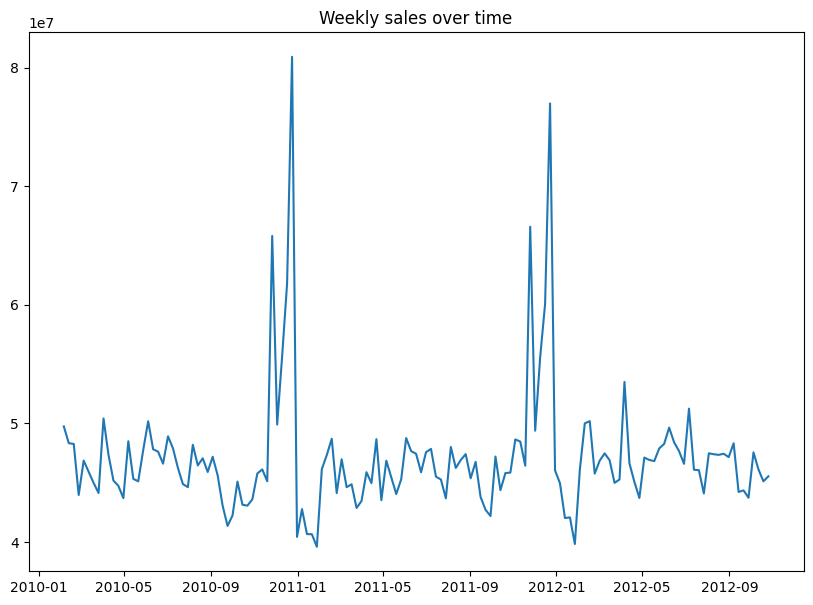

In [23]:
plt.figure(figsize = (10,7))
plt.plot(sales_over_time)
plt.title('Weekly sales over time')
plt.show()

In [24]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

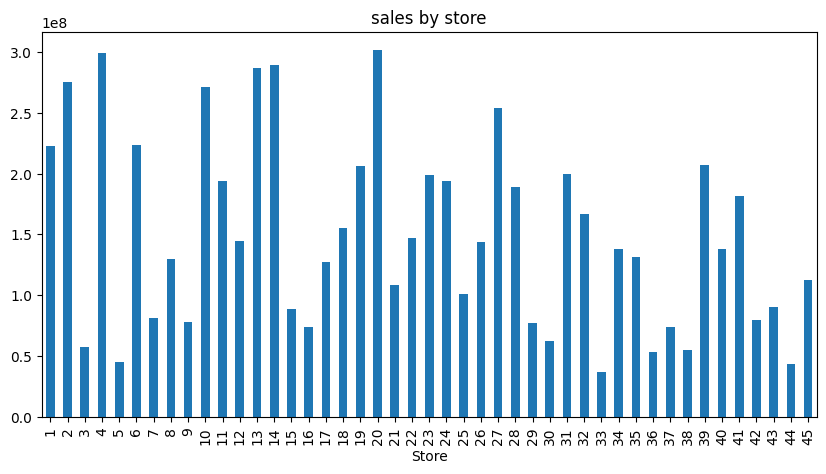

In [25]:
plt.figure(figsize = (10,5))
store_sales.plot(kind = 'bar')
plt.title('sales by store')
plt.show()

In [26]:
dept_sales = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending = False)

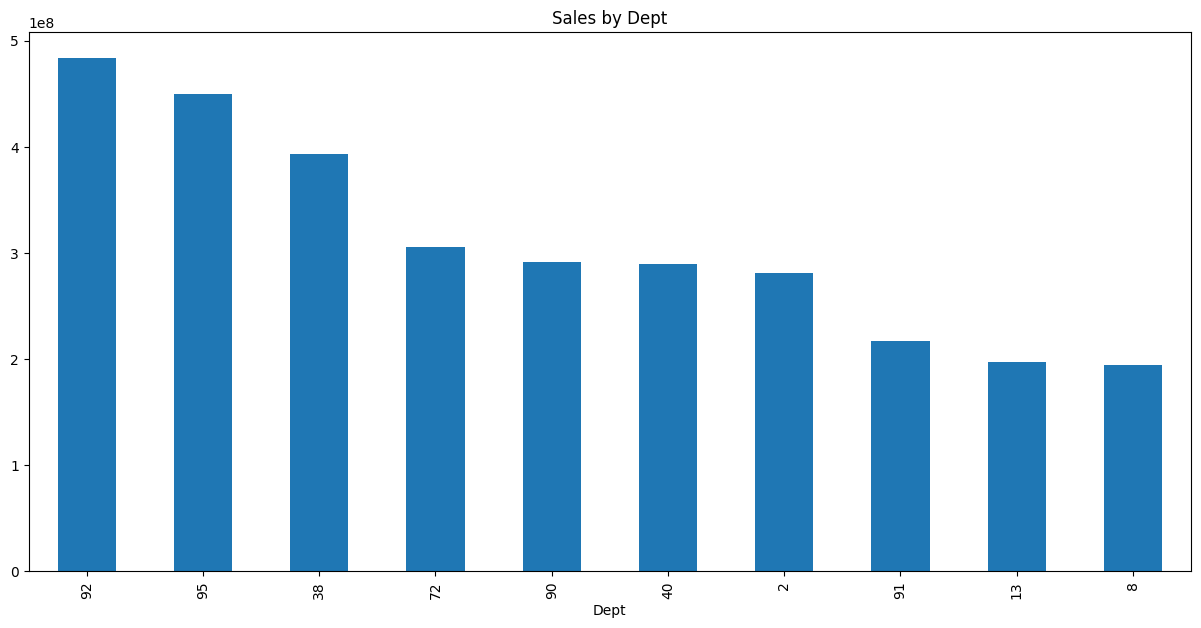

In [27]:
plt.figure(figsize = (15,7))
dept_sales.head(10).plot(kind = 'bar')
plt.title('Sales by Dept')
plt.show()

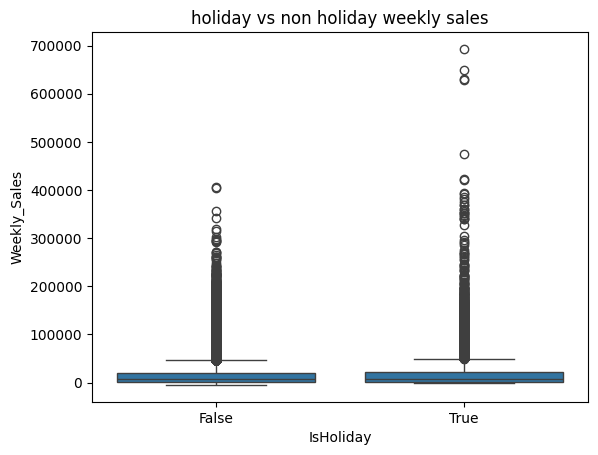

In [28]:
sns.boxplot(x = 'IsHoliday',y = 'Weekly_Sales',data = df)
plt.title('holiday vs non holiday weekly sales')
plt.show()

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

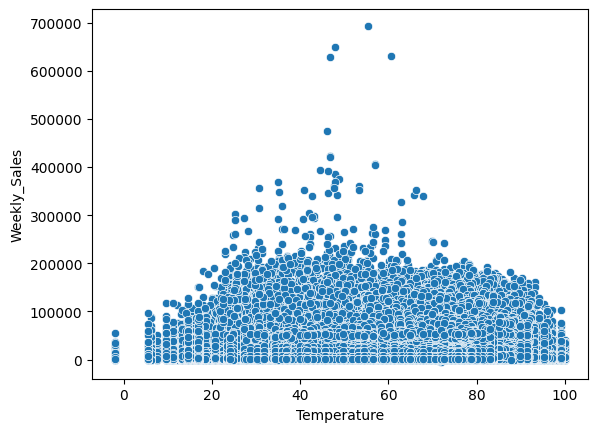

In [29]:
sns.scatterplot(x = 'Temperature',y = 'Weekly_Sales',data = df)

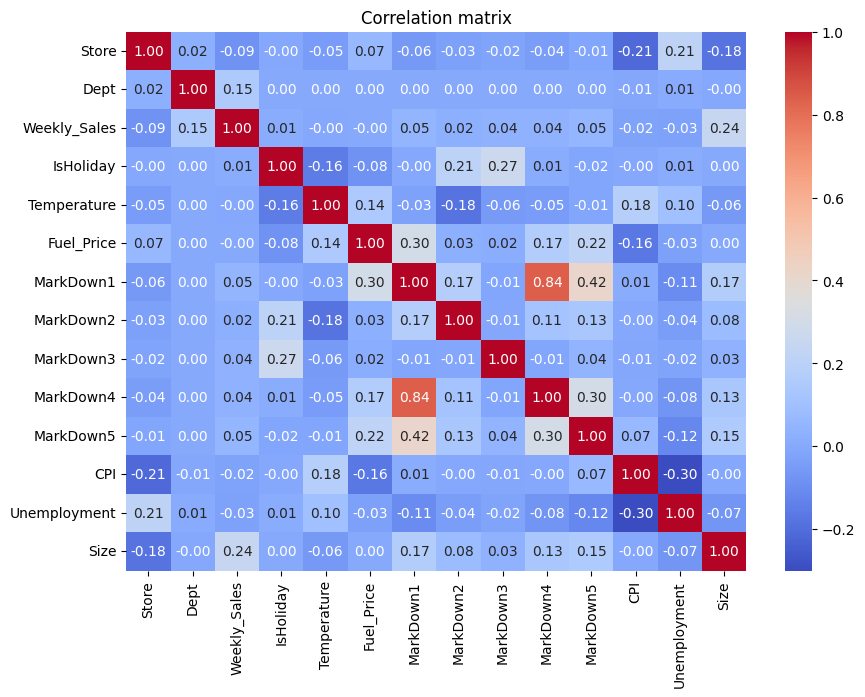

In [30]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.title('Correlation matrix')
plt.show()

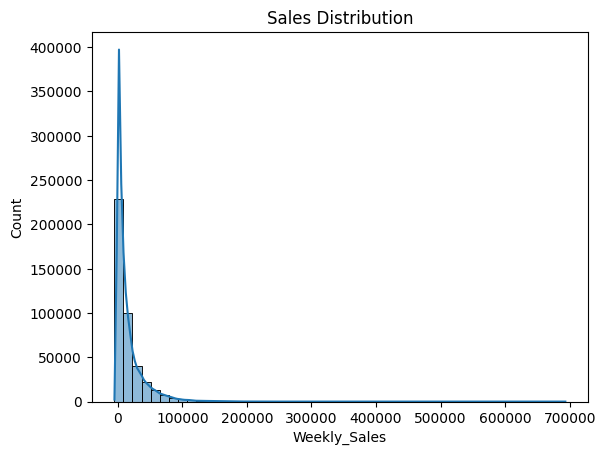

In [31]:
sns.histplot(df['Weekly_Sales'],bins = 50,kde = True)
plt.title('Sales Distribution')
plt.show()

In [32]:
df['month'] = df['Date'].dt.month

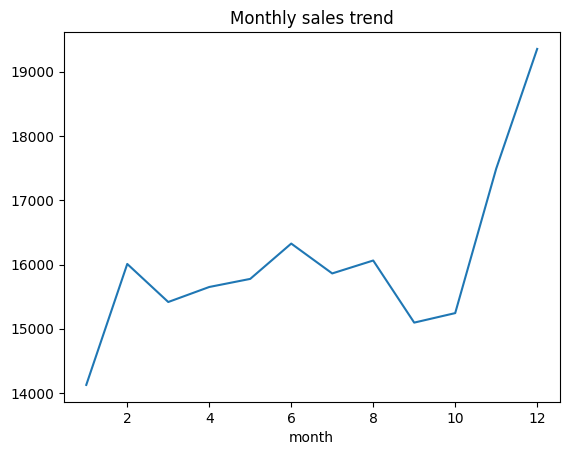

In [33]:
monthly_sales = df.groupby('month')['Weekly_Sales'].mean()
monthly_sales.plot()
plt.title('Monthly sales trend')
plt.show()

In [34]:
#1 Holiday weeks have higher sales
#2 Some stores generate much higher revenue
#3 Sales have seasonal patterns
#4 Temperature slightly impact sales

In [35]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [36]:
ts = df.groupby('Date')['Weekly_Sales'].sum()

In [37]:
ts.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

In [38]:
ts.index = pd.to_datetime(ts.index)

In [39]:
ts.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

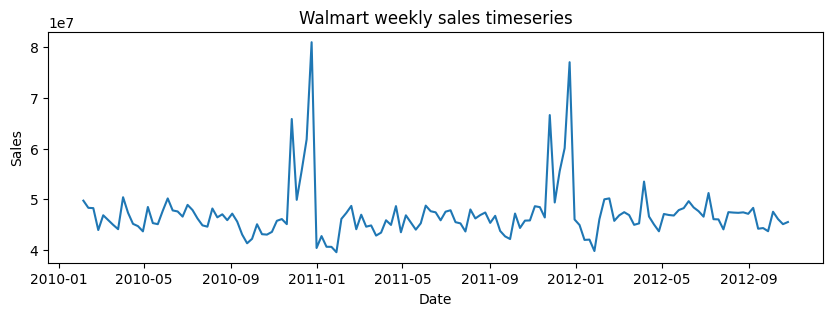

In [40]:
plt.figure(figsize = (10,3))
plt.plot(ts)
plt.title('Walmart weekly sales timeseries')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [41]:
rolling_mean = ts.rolling(window = 12).mean()
rolling_std = ts.rolling(window = 12).std()

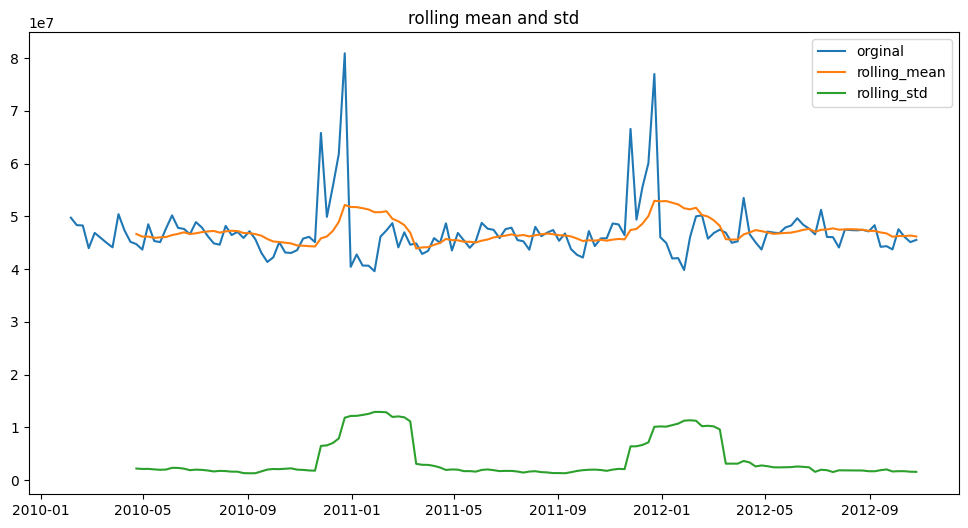

In [42]:
plt.figure(figsize = (12,6))
plt.plot(ts,label = 'orginal')
plt.plot(rolling_mean,label = 'rolling_mean')
plt.plot(rolling_std,label = 'rolling_std')
plt.title('rolling mean and std')
plt.legend()
plt.show()

In [43]:
def adf_test(series):
    result = adfuller(series)
    print('ADF Statics:',result[0])
    print('p_value:',result[1])
    for key,value in result[4].items():
        print('Critical Value:',key,value)

In [44]:
adf_test(ts)

ADF Statics: -5.908297957186334
p_value: 2.675979158986027e-07
Critical Value: 1% -3.47864788917503
Critical Value: 5% -2.882721765644168
Critical Value: 10% -2.578065326612056


In [45]:
# data is stationary since p_value < 0.05
# Weekly data → seasonality = 52 weeks

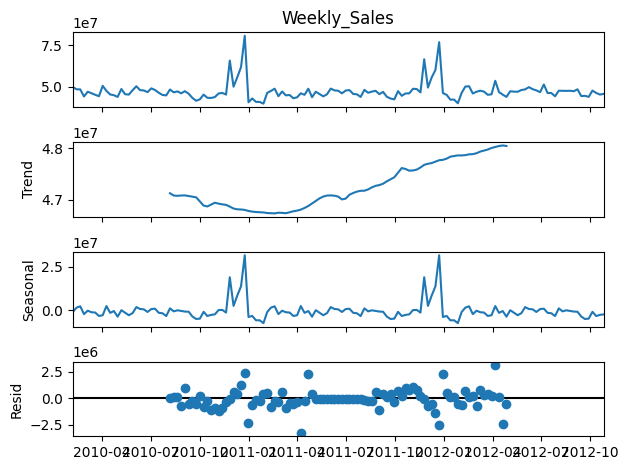

In [46]:
decomposition = seasonal_decompose(ts,model = 'aditive',period = 52)
decomposition.plot()
plt.show()

<Figure size 1000x600 with 0 Axes>

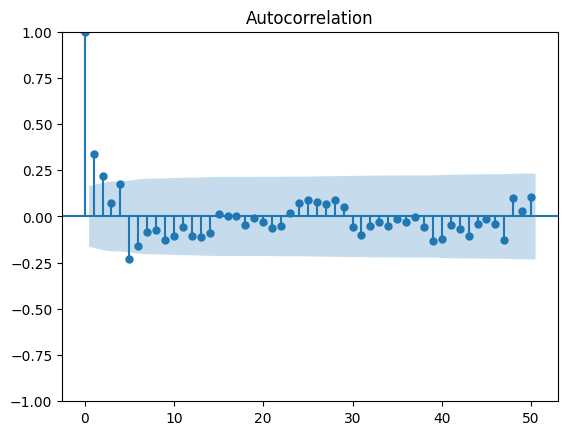

In [47]:
plt.figure(figsize = (10,6))
plot_acf(ts,lags = 50)
plt.show()

<Figure size 1000x600 with 0 Axes>

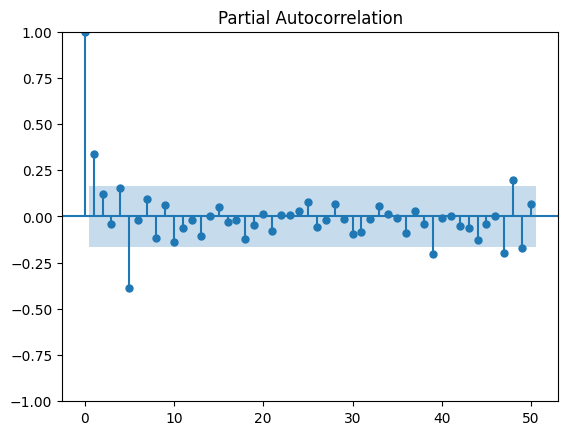

In [48]:
plt.figure(figsize = (10,6))
plot_pacf(ts,lags = 50)
plt.show()

In [49]:
#q = 3 p = 5 

In [50]:
from statsmodels.tsa.arima.model import ARIMA

In [51]:
model = ARIMA(ts,order = (5,0,3))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [52]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(5, 0, 3)   Log Likelihood               -2395.167
Date:                Fri, 06 Mar 2026   AIC                           4810.335
Time:                        15:34:33   BIC                           4839.963
Sample:                    02-05-2010   HQIC                          4822.374
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.711e+07   2.81e+05    167.932      0.000    4.66e+07    4.77e+07
ar.L1          0.2534      0.146      1.730      0.084      -0.034       0.541
ar.L2          0.4763      0.159      3.001      0.0

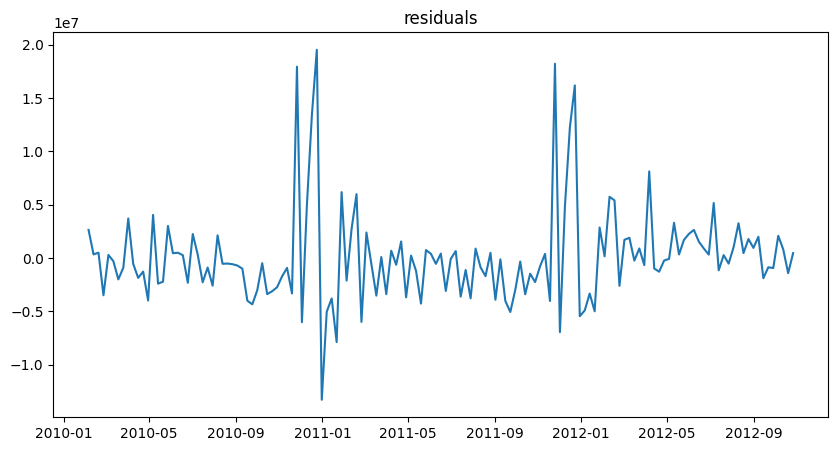

In [53]:
#To check the model
residual = model_fit.resid
plt.figure(figsize = (10,5))
plt.plot(residual)
plt.title('residuals')
plt.show()

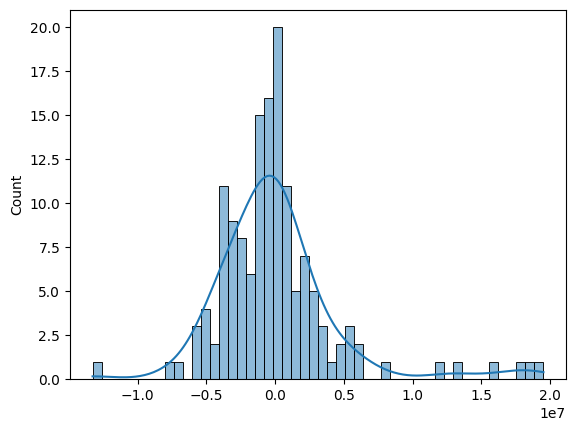

In [54]:
sns.histplot(residual,bins = 50,kde = True)
plt.show()

In [55]:
forecast = model_fit.forecast(steps = 12)
print(forecast)

2012-11-02    4.660066e+07
2012-11-09    4.609967e+07
2012-11-16    4.594343e+07
2012-11-23    4.671310e+07
2012-11-30    4.657017e+07
2012-12-07    4.647456e+07
2012-12-14    4.681593e+07
2012-12-21    4.689595e+07
2012-12-28    4.678668e+07
2013-01-04    4.696233e+07
2013-01-11    4.703268e+07
2013-01-18    4.698782e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


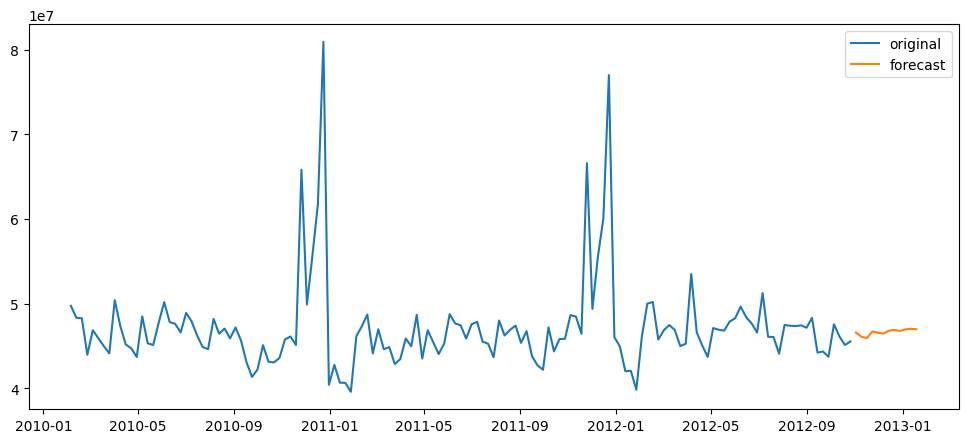

In [56]:
plt.figure(figsize = (12,5))
plt.plot(ts,label = 'original')
plt.plot(forecast,label = 'forecast')
plt.legend()
plt.show()

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [58]:
sarima_model = SARIMAX(ts,order = (5,0,3),seasonal_order = (1,1,1,52))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [59]:
sarima_fit = sarima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [60]:
print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                         Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(5, 0, 3)x(1, 1, [1], 52)   Log Likelihood               -1445.473
Date:                              Fri, 06 Mar 2026   AIC                           2912.946
Time:                                      15:35:14   BIC                           2940.565
Sample:                                  02-05-2010   HQIC                          2924.088
                                       - 10-26-2012                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7913      2.110     -0.375      0.708      -4.927       3.344
ar.L2          0.02

In [61]:
sarima_forecast = sarima_fit.forecast(steps = 12)

In [62]:
print(sarima_forecast)

2012-11-02    4.909812e+07
2012-11-09    4.907102e+07
2012-11-16    4.692970e+07
2012-11-23    6.726082e+07
2012-11-30    5.000680e+07
2012-12-07    5.612910e+07
2012-12-14    6.080674e+07
2012-12-21    7.795469e+07
2012-12-28    4.638044e+07
2013-01-04    4.544428e+07
2013-01-11    4.242157e+07
2013-01-18    4.255432e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


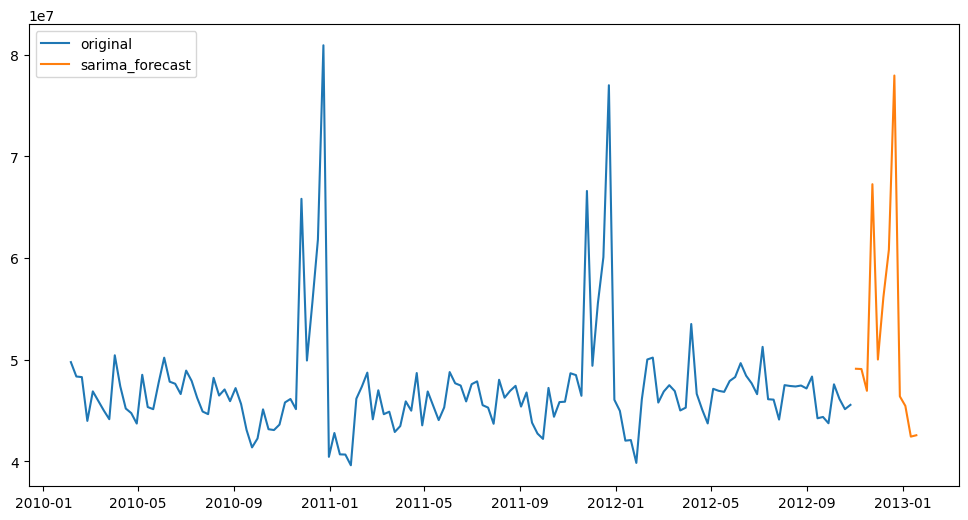

In [63]:
plt.figure(figsize = (12,6))
plt.plot(ts,label = 'original')
plt.plot(sarima_forecast,label = 'sarima_forecast')
plt.legend()
plt.show()

In [64]:
model2 = SARIMAX(ts,order = (1,0,1),seasonal_order = (1,1,1,52))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [65]:
result2 = model2.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [66]:
print(result2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood               -1445.439
Date:                            Fri, 06 Mar 2026   AIC                           2900.877
Time:                                    15:35:31   BIC                           2913.432
Sample:                                02-05-2010   HQIC                          2905.942
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8635      0.315      2.744      0.006       0.247       1.480
ma.L1         -0.8655      0.308   

In [67]:
forecast2 = result2.forecast(steps = 12)

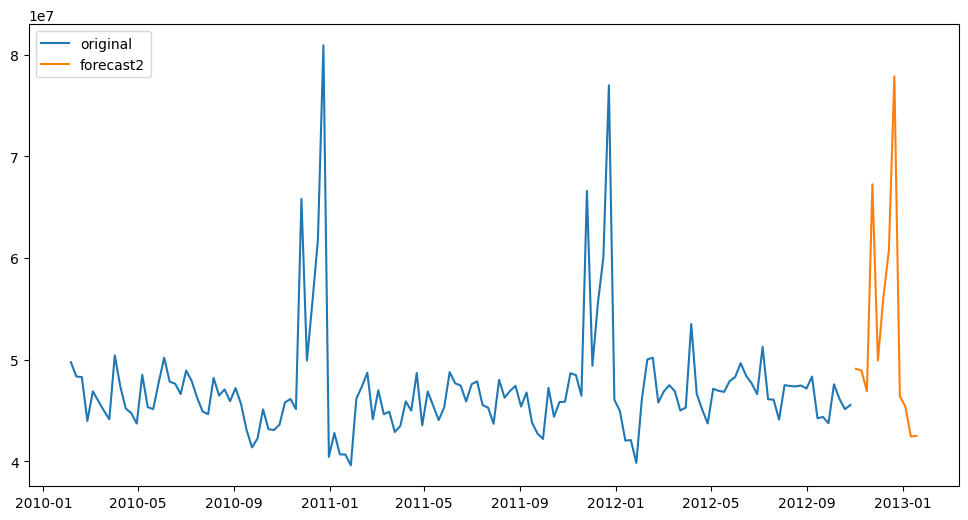

In [68]:
plt.figure(figsize = (12,6))
plt.plot(ts,label = 'original')
plt.plot(forecast2,label = 'forecast2')
plt.legend()
plt.show()

In [69]:
#The SARIMAX(1,0,1)(1,1,1,52) model produced statistically significant parameters and 
#lower AIC compared to the initial model.

#Diagnostic tests suggest residual independence and stable variance, indicating a well-fitted model.

#Therefore this model was selected for forecasting.

In [72]:
# Feature Engineering + Machine Learning

In [70]:
ts_df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

In [71]:
ts_df.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [74]:
ts_df['year'] = ts_df['Date'].dt.year
ts_df['month'] = ts_df['Date'].dt.month
ts_df['week'] = ts_df['Date'].dt.isocalendar().week
ts_df['day'] = ts_df['Date'].dt.day
ts_df['dayofweek'] = ts_df['Date'].dt.dayofweek
ts_df['quarter'] = ts_df['Date'].dt.quarter

In [75]:
ts_df.head()

,Date,Weekly_Sales,year,month,week,day,dayofweek,quarter
0,2010-02-05,49750740.50,2010,2,5,5,4,1
1,2010-02-12,48336677.63,2010,2,6,12,4,1
2,2010-02-19,48276993.78,2010,2,7,19,4,1
3,2010-02-26,43968571.13,2010,2,8,26,4,1
4,2010-03-05,46871470.30,2010,3,9,5,4,1


In [76]:
ts_df.tail()

,Date,Weekly_Sales,year,month,week,day,dayofweek,quarter
138,2012-09-28,43734899.40,2012,9,39,28,4,3
139,2012-10-05,47566639.31,2012,10,40,5,4,4
140,2012-10-12,46128514.25,2012,10,41,12,4,4
141,2012-10-19,45122410.57,2012,10,42,19,4,4
142,2012-10-26,45544116.29,2012,10,43,26,4,4


In [77]:
ts_df['lag_1'] = ts_df['Weekly_Sales'].shift(1)
ts_df['lag_2'] = ts_df['Weekly_Sales'].shift(2)
ts_df['lag_3'] = ts_df['Weekly_Sales'].shift(3)
ts_df['lag_4'] = ts_df['Weekly_Sales'].shift(4)

In [78]:
ts_df['lag_52'] = ts_df['Weekly_Sales'].shift(52)

In [79]:
# Rolling Mean Features For capturing Trend
ts_df['rolling_mean_4'] = ts_df['Weekly_Sales'].shift(1).rolling(window = 4).mean()
ts_df['rolling_mean_12'] = ts_df['Weekly_Sales'].shift(1).rolling(window = 12).mean()

In [80]:
ts_df['rolling_std_4'] = ts_df['Weekly_Sales'].shift(1).rolling(window=4).std()

In [82]:
ts_df.isnull().sum()

Date                0
Weekly_Sales        0
year                0
month               0
week                0
day                 0
dayofweek           0
quarter             0
lag_1               1
lag_2               2
lag_3               3
lag_4               4
lag_52             52
rolling_mean_4      4
rolling_mean_12    12
rolling_std_4       4
dtype: int64

In [83]:
ts_df.head()

,Date,Weekly_Sales,year,month,week,day,dayofweek,quarter,lag_1,lag_2,lag_3,lag_4,lag_52,rolling_mean_4,rolling_mean_12,rolling_std_4
0,2010-02-05,49750740.50,2010,2,5,5,4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-12,48336677.63,2010,2,6,12,4,1,49750740.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-02-19,48276993.78,2010,2,7,19,4,1,48336677.63,49750740.50,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-02-26,43968571.13,2010,2,8,26,4,1,48276993.78,48336677.63,49750740.50,NaN,NaN,NaN,NaN,NaN
4,2010-03-05,46871470.30,2010,3,9,5,4,1,43968571.13,48276993.78,48336677.63,49750740.5,NaN,47583245.76,NaN,2.504187e+06


In [84]:
ts_df.dropna(inplace = True)

In [85]:
ts_df.head()

,Date,Weekly_Sales,year,month,week,day,dayofweek,quarter,lag_1,lag_2,lag_3,lag_4,lag_52,rolling_mean_4,rolling_mean_12,rolling_std_4
52,2011-02-04,46153111.12,2011,2,5,4,4,1,39599852.99,40654648.03,40673678.04,42775787.77,49750740.50,4.092599e+07,5.079466e+07,1.331375e+06
53,2011-02-11,47336192.79,2011,2,6,11,4,1,46153111.12,39599852.99,40654648.03,40673678.04,48336677.63,4.177032e+07,5.079702e+07,2.964632e+06
54,2011-02-18,48716164.12,2011,2,7,18,4,1,47336192.79,46153111.12,39599852.99,40654648.03,48276993.78,4.343595e+07,5.098123e+07,3.874968e+06
55,2011-02-25,44125859.84,2011,2,8,25,4,1,48716164.12,47336192.79,46153111.12,39599852.99,43968571.13,4.545133e+07,4.955583e+07,4.039147e+06
56,2011-03-04,46980603.74,2011,3,9,4,4,1,44125859.84,48716164.12,47336192.79,46153111.12,46871470.30,4.658283e+07,4.907390e+07,1.944225e+06


In [86]:
# Feature Matrix

In [87]:
X = ts_df.drop(['Weekly_Sales','Date'],axis = 1)
y = ts_df['Weekly_Sales']

In [88]:
# Train Test Split In Time Series we do not perform random split

In [89]:
split = int(len(ts_df)*0.8)

In [90]:
x_train = X[:split]
x_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [92]:
from sklearn.ensemble import RandomForestRegressor

In [93]:
rf_model = RandomForestRegressor(n_estimators = 200,max_depth = 10,random_state = 42)

In [94]:
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [95]:
rf_pred = rf_model.predict(x_test)

In [96]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [97]:
mae = mean_absolute_error(y_test,rf_pred)
print(mae)

857731.8368424103


In [98]:
rmse = np.sqrt(mean_squared_error(y_test,rf_pred))
print(rmse)

1190412.8375350179


In [102]:
print("RandomForest MAE:",mae)
print("RandomForest RMSE:",rmse)

RandomForest MAE: 857731.8368424103
RandomForest RMSE: 1190412.8375350179


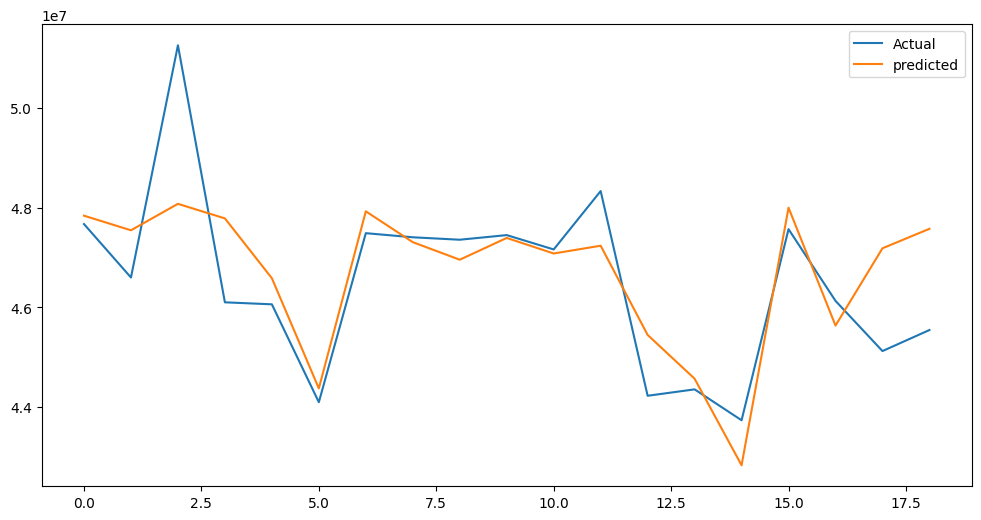

In [104]:
plt.figure(figsize = (12,6))
plt.plot(y_test.values,label = 'Actual')
plt.plot(rf_pred,label = 'predicted')
plt.legend()
plt.show()

In [105]:
from xgboost import XGBRegressor

In [106]:
xgb_model = XGBRegressor(n_estimators = 500,learing_rate = 0.05,max_depth = 6)

In [107]:
xgb_model.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learing_rate=0.05, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None, ...)

In [108]:
xgb_pred = xgb_model.predict(x_test)

In [111]:
xgb_mae = mean_absolute_error(y_test,xgb_pred)
xgb_mse = np.sqrt(mean_squared_error(y_test,xgb_pred))
print('XGB Mae:',xgb_mae)
print('XGB Mse:',xgb_mse)

XGB Mae: 881566.785263158
XGB Mse: 1236827.9590972953


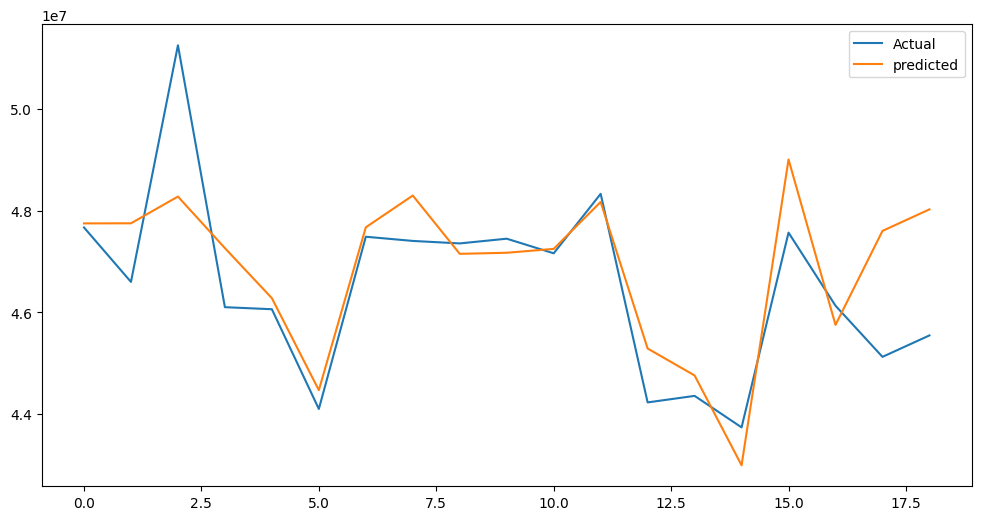

In [112]:
plt.figure(figsize = (12,6))
plt.plot(y_test.values,label = 'Actual')
plt.plot(xgb_pred,label = 'predicted')
plt.legend()
plt.show()

In [114]:
print("RF RMSE:",rmse)
print("XGB RMSE:",xgb_mse)

RF RMSE: 1190412.8375350179
XGB RMSE: 1236827.9590972953


In [117]:
# For SARIMAX MODEL

In [121]:
train = ts[:split]
test = ts[split:]

In [122]:
sarimax_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,52)
)

sarimax_fit = sarimax_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [123]:
sarimax_pred = sarimax_fit.forecast(steps=len(test))
mae_sarimax = mean_absolute_error(test, sarimax_pred)
rmse_sarimax = np.sqrt(mean_squared_error(test, sarimax_pred))

print("SARIMAX MAE:",mae_sarimax)
print("SARIMAX RMSE:",rmse_sarimax)

SARIMAX MAE: 1894811.7335045296
SARIMAX RMSE: 2354377.9242902645


In [125]:
print("SARIMAX RMSE:", rmse_sarimax)
print("RandomForest RMSE:", rmse)
print("XGBoost RMSE:", xgb_mse)

SARIMAX RMSE: 2354377.9242902645
RandomForest RMSE: 1190412.8375350179
XGBoost RMSE: 1236827.9590972953


Three models were evaluated:

SARIMAX
RandomForest
XGBoost

RandomForest achieved the lowest RMSE (1.19M)
compared to XGBoost (1.23M).

Considering the weekly sales scale (~50M),
the error rate is around 2%, indicating strong
predictive performance.

Therefore RandomForest was selected as the
final forecasting model.

In [126]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [127]:
prophet_df = ts.reset_index()

In [128]:
prophet_df.head()

,Date,Weekly_Sales
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [131]:
prophet_df.columns = ['ds','y']

In [132]:
prophet_df.head()

,ds,y
0,2010-02-05,49750740.50
1,2010-02-12,48336677.63
2,2010-02-19,48276993.78
3,2010-02-26,43968571.13
4,2010-03-05,46871470.30


In [133]:
train_prophet = prophet_df[:split]
test_prophet = prophet_df[split:]

In [135]:
from prophet import Prophet

In [136]:
model_prophet = Prophet(yearly_seasonality = True,weekly_seasonality = False,daily_seasonality = False)

In [137]:
model_prophet.fit(train_prophet)

17:35:28 - cmdstanpy - INFO - Chain [1] start processing
17:35:28 - cmdstanpy - INFO - Chain [1] done processing


In [139]:
future = model_prophet.make_future_dataframe(
    periods=len(test_prophet),
    freq="W"
)

In [140]:
forecast = model_prophet.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,4.759948e+07,4.407148e+07,5.311866e+07,4.759948e+07,4.759948e+07,8.377640e+05,8.377640e+05,8.377640e+05,8.377640e+05,8.377640e+05,8.377640e+05,0.0,0.0,0.0,4.843724e+07
1,2010-02-12,4.758239e+07,4.423002e+07,5.357832e+07,4.758239e+07,4.758239e+07,1.322834e+06,1.322834e+06,1.322834e+06,1.322834e+06,1.322834e+06,1.322834e+06,0.0,0.0,0.0,4.890522e+07
2,2010-02-19,4.756530e+07,4.250648e+07,5.206819e+07,4.756530e+07,4.756530e+07,-2.318827e+05,-2.318827e+05,-2.318827e+05,-2.318827e+05,-2.318827e+05,-2.318827e+05,0.0,0.0,0.0,4.733342e+07
3,2010-02-26,4.754821e+07,4.136908e+07,5.102531e+07,4.754821e+07,4.754821e+07,-1.440843e+06,-1.440843e+06,-1.440843e+06,-1.440843e+06,-1.440843e+06,-1.440843e+06,0.0,0.0,0.0,4.610737e+07
4,2010-03-05,4.753112e+07,4.135861e+07,5.048265e+07,4.753112e+07,4.753112e+07,-1.588219e+06,-1.588219e+06,-1.588219e+06,-1.588219e+06,-1.588219e+06,-1.588219e+06,0.0,0.0,0.0,4.594290e+07


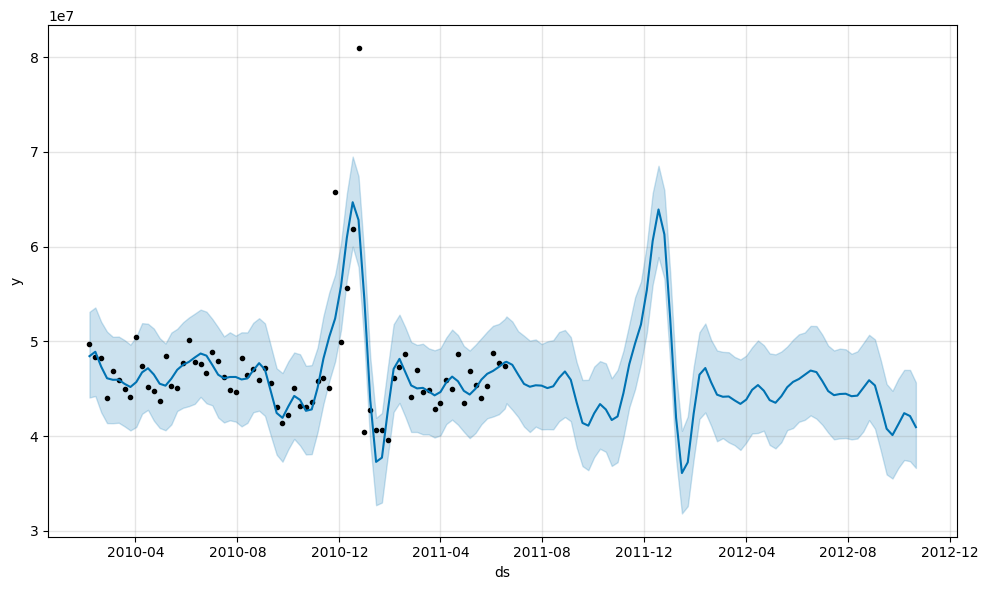

In [141]:
model_prophet.plot(forecast)
plt.show()

In [142]:
prophet_pred = forecast["yhat"].iloc[-len(test_prophet):].values

In [143]:
mae_prophet = mean_absolute_error(test_prophet["y"],prophet_pred)

rmse_prophet = np.sqrt(mean_squared_error(test_prophet["y"],prophet_pred))

print("Prophet MAE:",mae_prophet)
print("Prophet RMSE:",rmse_prophet)

Prophet MAE: 2991181.3053953387
Prophet RMSE: 4346739.4375508055


In [144]:
print("SARIMAX RMSE:",rmse_sarimax)
print("RandomForest RMSE:",rmse)
print("XGBoost RMSE:",xgb_mse)
print("Prophet RMSE:",rmse_prophet)

SARIMAX RMSE: 2354377.9242902645
RandomForest RMSE: 1190412.8375350179
XGBoost RMSE: 1236827.9590972953
Prophet RMSE: 4346739.4375508055


In [145]:
#  Best Model is RandomForest